In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

import matplotlib.pyplot as plt
import matplotlib
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

import ast
pd.set_option('display.max_columns', None)
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import seaborn as sns
import warnings # To suppress some warnings
import plotly.graph_objects as go
import plotly.express as px

# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# Add the classifiers to the imports here:
# ANSWER STARTING HERE

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import GradientBoostingClassifier

import hashlib
from sklearn.preprocessing import MinMaxScaler

In [40]:
df = pd.read_csv("diabetes_dataset.csv")

df = df[df['ldl_cholesterol'] > 50]

df = df[df['insulin_level'] > 2]



X = df[['ldl_cholesterol','insulin_level','hba1c','waist_to_hip_ratio']]
Y = df[['diabetes_stage']]

Y['diabetes_num'] = Y['diabetes_stage'].apply(lambda x: 0 if x == 'No Diabetes' else (1 if x == 'Pre-Diabetes' else (2 if x == 'Type 1' else (3 if x == 'Type 2' else (4 if x == 'Gestational' else -1)))))

# no missing diabetes stage labels
print(Y[Y['diabetes_num'] == -1].sum())



diabetes_stage    0
diabetes_num      0
dtype: object


/tmp/ipykernel_6872/2186020059.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y['diabetes_num'] = Y['diabetes_stage'].apply(lambda x: 0 if x == 'No Diabetes' else (1 if x == 'Pre-Diabetes' else (2 if x == 'Type 1' else (3 if x == 'Type 2' else (4 if x == 'Gestational' else -1)))))


No Diabetes Count:  6198
Pre Diabetes Count:  26013
Type 1 Diabetes Count:  90
Type 2 Diabetes Count:  50520
Gestational Diabetes Count:  217


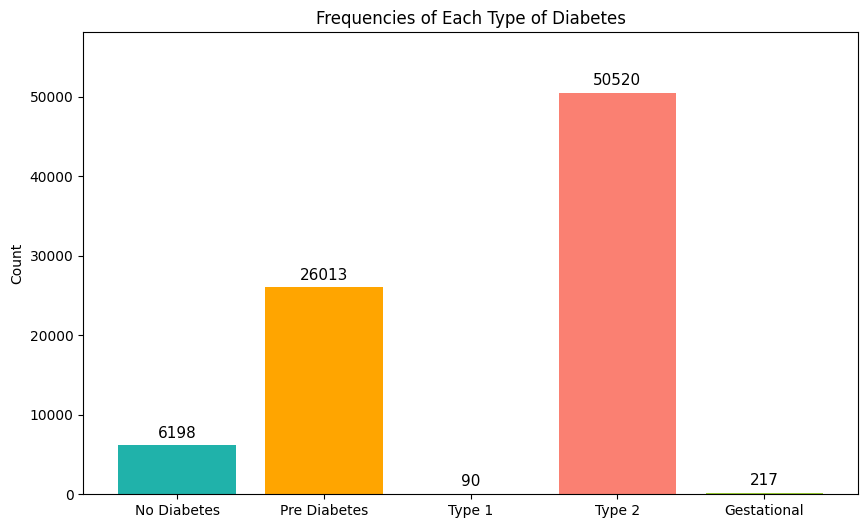

In [42]:
No_diabetes_freq = Y[Y['diabetes_num'] == 0]['diabetes_num'].count()
Pre_diabetes_freq = Y[Y['diabetes_num'] == 1]['diabetes_num'].count()
Type1_diabetes_freq = Y[Y['diabetes_num'] == 2]['diabetes_num'].count()
Type2_diabetes_freq = Y[Y['diabetes_num'] == 3]['diabetes_num'].count()
Gestational_diabetes_freq = Y[Y['diabetes_num'] == 4]['diabetes_num'].count()


print("No Diabetes Count: ", No_diabetes_freq);
print("Pre Diabetes Count: ", Pre_diabetes_freq);
print("Type 1 Diabetes Count: ", Type1_diabetes_freq);
print("Type 2 Diabetes Count: ", Type2_diabetes_freq);
print("Gestational Diabetes Count: ", Gestational_diabetes_freq);


Freq_list = [No_diabetes_freq, Pre_diabetes_freq, Type1_diabetes_freq, Type2_diabetes_freq, Gestational_diabetes_freq]
dtype = ['No Diabetes', 'Pre Diabetes', 'Type 1', 'Type 2', 'Gestational']
bar_colors = ['lightseagreen', 'orange', 'deepskyblue', 'salmon', 'yellowgreen']


fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(dtype, Freq_list, color=bar_colors)
ax.bar_label(bars, padding=3, fontsize=11)


ax.set_ylim(0, max(Freq_list) * 1.15)
ax.set_ylabel('Count')
ax.set_title('Frequencies of Each Type of Diabetes')


plt.show()

In [43]:
seed = 67
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, Y['diabetes_num'], test_size=test_size, random_state=seed, stratify=Y['diabetes_num'])

In [46]:
from sklearn.utils.class_weight import compute_sample_weight

# 'y_train' represents your target labels
classes = np.unique(y_train)

# Calculate weights based on the 'balanced' heuristic
# We compute sample weight instead of class weight because some of our models do not have a class_weight parameter
weights = compute_sample_weight(class_weight='balanced', y=y_train)

In [47]:
# Scale the X values (and not Y, as Y are labels and thus do not need scaling)
scaler = StandardScaler().fit(X)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
models = {
    'Logistic Regression': LogisticRegression(random_state=seed,max_iter=1000),
    'Gradient Boosting' : GradientBoostingClassifier(random_state=seed),
    'Decision Tree'    : DecisionTreeClassifier(random_state=seed),
    'Random Forest'    : RandomForestClassifier(random_state=seed),
    'KNN'              : KNeighborsClassifier()
}

In [17]:
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)

for model_name, model in models.items():
    np.random.seed(42)
    print(f"Model: {model_name}")

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf)
    print(f"Cross-validated Accuracy: {cv_scores.mean()} (+/- {cv_scores.std()})")

Model: Logistic Regression
Cross-validated Accuracy: 0.7936474484419691 (+/- 0.002111026888245732)
Model: Gradient Boosting
Cross-validated Accuracy: 0.8588589492699082 (+/- 0.0007956992495199561)
Model: Decision Tree
Cross-validated Accuracy: 0.7973054342917356 (+/- 0.002576294067162002)
Model: Random Forest
Cross-validated Accuracy: 0.8520547945205479 (+/- 0.0011281044103685072)
Model: KNN
Cross-validated Accuracy: 0.8261779316573836 (+/- 0.001532644213302461)


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer

updated_param_list = {}

for model_name, model in models.items():
    param_grid = {}
    if model_name == 'Logistic Regression':
        param_grid = {'max_iter': [1000, 2000, 3000],
                      'C': [0.01, 0.1, 1, 10]}
    elif model_name == 'Gradient Boosting':
        param_grid = {'n_estimators': [100, 200],
                    'learning_rate': [0.01, 0.1, 0.2],
                    'max_depth': [3, 5, 7]}
    elif model_name == 'Decision Tree':
        param_grid = {'max_depth': [None, 10, 20, 30],
                    'min_samples_split': [2, 5, 10]}
    elif model_name == 'Random Forest':
        param_grid = {'n_estimators': [100, 200],
                    'max_depth': [None, 10, 20, 30],
                    'min_samples_split': [2, 5, 10]}
    else:
        continue

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='recall_macro', n_jobs=-1)
    grid_search.fit(X_train, y_train, sample_weight=weights)
    models[model_name] = grid_search.best_estimator_

    updated_param_list[model_name] = grid_search.best_params_

for model_name,params in updated_param_list.items():
    print(model_name + ": ")
    print(params)


KeyboardInterrupt: 

In [ ]:
# Train each model using the training data
for model_name, model in models.items():
    # Set random seed for reproducibility
    np.random.seed(seed)

    model.fit(X_train_scaled, y_train, sample_weight=weights)

# Evaluate the performance of each model
for model_name, model in models.items():
    np.random.seed(seed)

    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test,y_pred)
    print(f"Accuracy of {model_name}: {accuracy:.3f}") # Your accuracy table header here
    print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2', 'Gestational']))

In [ ]:
# Extract the feature importances from the most accurate model
importances1 = models['Gradient Boosting'][1].feature_importances_
importances2 = models['Decision Tree'][1].feature_importances_
importances3 = models['Random Forest'][1].feature_importances_


# Creating a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({0:importances1,1:importances2,2:importances3},index=X.columns).sort_values(by=[0], ascending=False)
# Displaying feature importances
# print("Feature Importances:")
# print(feature_importance_df[:4])
# print(X.columns)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))
axes = axes.flatten()  # Make it easier to index
feature_list = [importances1, importances2, importances3]

for i, feature in enumerate(feature_list) :
    ax = axes[i]

    feature_importance = pd.Series(feature, index = X.columns).sort_values(ascending=False)
    ax.barh(feature_importance .index, feature_importance.values, color='mediumseagreen', edgecolor='black')
    ax.set_xlabel('Importance')
    ax.set_title('Feature Importances')

plt.tight_layout()
plt.show()

In [ ]:
total_pd = df[['ldl_cholesterol','insulin_level','hba1c','waist_to_hip_ratio']]
total_pd['diabetes_num'] = Y['diabetes_num']


corr = total_pd .corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title("Correlation Matrix for Diabetes Features", fontsize=14, fontweight='bold')
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
cax = ax.matshow(corr, cmap='coolwarm')
fig.colorbar(cax)


ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)), corr.columns)
plt.show()